In [98]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as pltimport
print(torch.__version__)
print(torch.cuda.is_available())


2.9.0+cpu
False


In [99]:
scalar = torch.tensor(7)
scalar

tensor(7)

In [100]:
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)

In [101]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

In [102]:
x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_np} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 2],
        [3, 4]]) 

Random Tensor: 
 tensor([[0.8504, 0.5406],
        [0.3701, 0.7694]]) 



In [103]:
shape = (2,3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.4990, 0.8414, 0.9926],
        [0.3130, 0.3053, 0.7060]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [104]:
tensor = torch.rand(3,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


In [105]:
# We move our tensor to the current accelerator if available
if torch.accelerator.is_available():
    tensor = tensor.to(torch.accelerator.current_accelerator())

In [106]:
tensor = torch.ones(5, 5)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:, 0]}")
print(f"Last column: {tensor[..., -1]}")
tensor[:,1] = 0
print(tensor)

First row: tensor([1., 1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1., 1.])
tensor([[1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1.]])


In [107]:
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1)

tensor([[1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1.]])


In [108]:
# This computes the matrix multiplication between two tensors. y1, y2, y3 will have the same value
# ``tensor.T`` returns the transpose of a tensor
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)

y3 = torch.rand_like(y1)
torch.matmul(tensor, tensor.T, out=y3)


# This computes the element-wise product. z1, z2, z3 will have the same value
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.rand_like(tensor)
torch.mul(tensor, tensor, out=z3)

tensor([[1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1.]])

In [109]:
agg = tensor.sum()
agg_item = agg.item()
print(agg_item, type(agg_item))

20.0 <class 'float'>


In [110]:
print(f"{tensor} \n")
tensor.add_(5)
print(tensor)

tensor([[1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1.],
        [1., 0., 1., 1., 1.]]) 

tensor([[6., 5., 6., 6., 6.],
        [6., 5., 6., 6., 6.],
        [6., 5., 6., 6., 6.],
        [6., 5., 6., 6., 6.],
        [6., 5., 6., 6., 6.]])


In [111]:
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]


In [112]:
t.add_(1)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


In [113]:
n = np.ones(5)
t = torch.from_numpy(n)

In [114]:
np.add(n, 1, out=n)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
n: [2. 2. 2. 2. 2.]


In [115]:
one_to_ten = torch.arange(start=1, end=11, step=1)
one_to_ten

tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [116]:
#Creating tensors like
ten_zeros = torch.zeros_like(input = one_to_ten )
ten_zeros

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [117]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [118]:
float_32_torch = torch.tensor([3.0, 6.0, 9.0],
                              dtype = None,
                              device= "cpu",
                              requires_grad = False)

float_32_torch

tensor([3., 6., 9.])

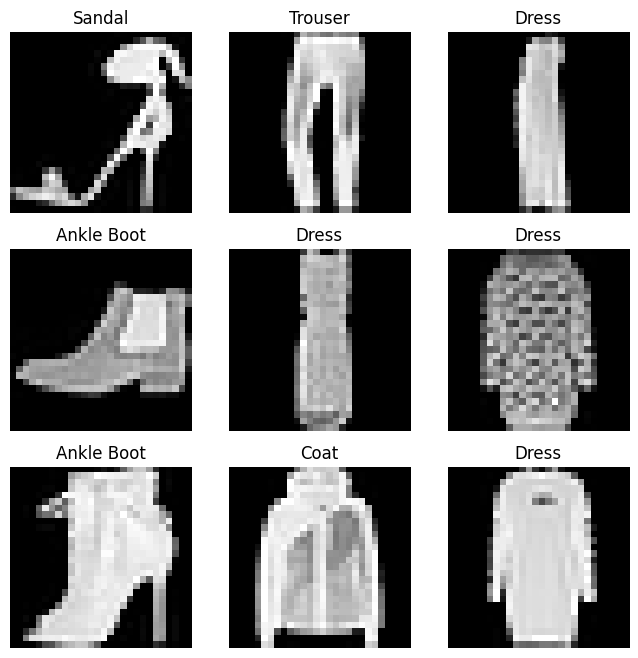

In [119]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [120]:
float_32_torch.dtype

torch.float32

In [121]:
float_16_tensor = float_32_torch.type(torch.float16)
float_16_tensor

tensor([3., 6., 9.], dtype=torch.float16)

In [122]:
int_32_torch = torch.tensor([3, 6, 9], dtype = torch.int32)
int_32_torch

tensor([3, 6, 9], dtype=torch.int32)

In [123]:
some_tensor = torch.rand(3, 4)
some_tensor

tensor([[0.1839, 0.7570, 0.8997, 0.6257],
        [0.5735, 0.9500, 0.3519, 0.5264],
        [0.3671, 0.5436, 0.7109, 0.7137]])

In [124]:
#Lets find out details about some tensor

print(some_tensor)
print(f'Datatype of tensor: {some_tensor.dtype}')
print(f'Shape of tensor: {some_tensor.shape}')
print(f'Device tensor is on: {some_tensor.device}')

tensor([[0.1839, 0.7570, 0.8997, 0.6257],
        [0.5735, 0.9500, 0.3519, 0.5264],
        [0.3671, 0.5436, 0.7109, 0.7137]])
Datatype of tensor: torch.float32
Shape of tensor: torch.Size([3, 4])
Device tensor is on: cpu


In [125]:
some_tensor.size()

torch.Size([3, 4])

In [126]:
## Manipulating Tensors(tensor operations)

tensor = torch.tensor([1, 2, 3])
tensor + 10

tensor([11, 12, 13])

In [127]:
tensor * 10

tensor([10, 20, 30])

In [128]:
tensor

tensor([1, 2, 3])

In [129]:
tensor - 10

tensor([-9, -8, -7])

In [130]:
torch.mul(tensor, 10)

tensor([10, 20, 30])

In [131]:
# Creating tensors
import torch

# From a Python list
x = torch.tensor([1, 2, 3, 4])
print(type(x))  # <class 'torch.Tensor'>

# A 2D tensor (matrix)
matrix = torch.tensor([[1, 2], [3, 4]])

# Random tensor (like an image with 1 channel, 28x28 pixels)
image_tensor = torch.randn(1, 28, 28)

# Operations on tensors
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])
c = a + b  # Element-wise addition
print(c)  # tensor([5., 7., 9.])

<class 'torch.Tensor'>
tensor([5., 7., 9.])


In [132]:
##Matrix Multiplication
tensor * tensor



tensor([1, 4, 9])

In [133]:
torch.matmul(tensor, tensor)

tensor(14)

In [134]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

In [135]:
x_original = torch.rand(size=(224, 224, 3))

#permute teh origina tensor to rearrange the axis
x_permuted = x_original.permute(2, 0, 1)

print(f"Previous shape : {x_original.shape}")
print(f"New shape: {x_permuted.shape}")

Previous shape : torch.Size([224, 224, 3])
New shape: torch.Size([3, 224, 224])


In [136]:
x_original

tensor([[[0.7813, 0.8513, 0.1426],
         [0.6810, 0.6745, 0.8219],
         [0.5179, 0.6573, 0.8146],
         ...,
         [0.4977, 0.6618, 0.8102],
         [0.1938, 0.7166, 0.5378],
         [0.5484, 0.2321, 0.1033]],

        [[0.3837, 0.8611, 0.6293],
         [0.1641, 0.6605, 0.6296],
         [0.1613, 0.9801, 0.2545],
         ...,
         [0.6925, 0.3591, 0.9440],
         [0.5465, 0.9820, 0.4741],
         [0.5911, 0.1133, 0.9346]],

        [[0.7763, 0.8782, 0.4873],
         [0.7004, 0.7096, 0.4885],
         [0.6339, 0.8065, 0.0557],
         ...,
         [0.4672, 0.8027, 0.9993],
         [0.4318, 0.2504, 0.2135],
         [0.8117, 0.7360, 0.5141]],

        ...,

        [[0.4061, 0.5879, 0.5707],
         [0.7578, 0.5646, 0.0993],
         [0.2938, 0.0446, 0.0412],
         ...,
         [0.9811, 0.2090, 0.8693],
         [0.2472, 0.6623, 0.6331],
         [0.1420, 0.4484, 0.2360]],

        [[0.1968, 0.2552, 0.3616],
         [0.2850, 0.3494, 0.7244],
         [0.

In [137]:
x_original [0, 0, 0]

tensor(0.7813)

In [138]:
tensor_matrix = torch.tensor([[[1, 2, 3],
                               [4, 5, 6],
                               [7, 8, 9]]])

In [139]:
tensor_matrix [:,:,-1]

tensor([[3, 6, 9]])

In [140]:
array = np.arange(1.0, 8.0)
tensor = torch.from_numpy(array)
array,tensor

(array([1., 2., 3., 4., 5., 6., 7.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [141]:
#Change the value of the array, what will this do to 'tensor'

array = array + 1
array , tensor

(array([2., 3., 4., 5., 6., 7., 8.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

In [142]:
#Tensor to numpy

tensor = torch.ones (7)
numpy_tensor = tensor.numpy()
tensor, numpy_tensor


(tensor([1., 1., 1., 1., 1., 1., 1.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

In [143]:
#Change the tnesor, what happens to 'numpy_tesnor'?
tensor = tensor + 1
tensor

tensor([2., 2., 2., 2., 2., 2., 2.])

In [151]:
##Reproducability (trying to take random out of random )
import torch
random_tensorA = torch.rand(3, 4)
random_tensorB = torch.rand(3, 4)
print(random_tensorA)
print(random_tensorB)
print(random_tensorA == random_tensorB)


tensor([[0.9469, 0.8739, 0.2575, 0.4769],
        [0.8145, 0.0716, 0.1843, 0.4982],
        [0.8484, 0.6842, 0.4520, 0.7325]])
tensor([[0.1844, 0.5549, 0.1654, 0.5846],
        [0.8915, 0.1437, 0.5747, 0.5462],
        [0.2016, 0.4207, 0.8993, 0.0714]])
tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])


In [158]:
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
random_tensorC = torch.rand(3, 4)

torch.manual_seed(RANDOM_SEED)
random_tensorD = torch.rand(3, 4)

print(random_tensorC)
print(random_tensorD)
print(random_tensorC == random_tensorD)


tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])


Running tensors and PyTorch objects on the GPUs